# quick data_preporcessing and visulization


visulize data

sepreate data into bening and attack and remove labels

In [ ]:
import dask.dataframe as dd

# Load all parquet files (schema may vary between partitions)
df = dd.read_parquet("merged_nids.csv", engine="pyarrow")

# Make sure only keep numeric + Label (drop inconsistent columns)
keep_cols = [c for c in df.columns if c not in ["Flow ID", "Src IP", "Src Port", "Dst IP", "Dst Port", "Protocol"]]

df_clean = df[keep_cols]

# Save back as a single clean parquet
df_clean.to_csv(
    "merged_cic2018_clean.csv",
    
    write_index=False
)


In [39]:
import dask.dataframe as dd
import numpy as np
import os

# Load dataset lazily
df = dd.read_csv("attack_majority_nids.csv", engine="pyarrow")

# Replace ±inf with NaN for all numeric columns
df = df.replace([np.inf, -np.inf], np.nan)

# Drop rows with any NaN values
df = df.dropna()

# Keep only attacks
df_attack = df[df['label'] != 'BENIGN']

# Create output folder for attacks
attack_output_dir = "attacks"
os.makedirs(attack_output_dir, exist_ok=True)

# Get unique attack types (compute small array in memory)
attack_types = df_attack['label'].unique().compute()

# Save each attack type separately
for attack_type in attack_types:
    safe_name = str(attack_type).replace(" ", "_").replace("/", "_")  # avoid bad filename chars
    file_path = os.path.join(attack_output_dir, f"{safe_name}.csv")

    df_filtered = df_attack[df_attack['label'] == attack_type]
    df_filtered.to_csv(file_path, index=False, single_file=True)  # single_file=True is key!

    print(f"Saved {attack_type} -> {file_path}")

print("✅ All attacks saved separately!")
df = dd.read_csv("undersampled_CIC2017_dataset.csv", engine="pyarrow")
# Keep only BENIGN (exclude all attacks)
df_benign = df[df['label'] == 'BENIGN']

# Create output folder for benign
benign_output_dir = "benign_only"
os.makedirs(benign_output_dir, exist_ok=True)

# Save only benign traffic
file_path = os.path.join(benign_output_dir, "benign_only.csv")
df_benign.to_csv(file_path, index=False, single_file=True)

print(f"✅ Saved BENIGN-only data to {file_path}")
print(f"Total benign samples: {len(df_benign)}")

Saved Bot -> attacks\Bot.csv
Saved DoS GoldenEye -> attacks\DoS_GoldenEye.csv
Saved DoS Hulk -> attacks\DoS_Hulk.csv
Saved DoS Slowhttptest -> attacks\DoS_Slowhttptest.csv
Saved FTP-Patator -> attacks\FTP-Patator.csv
Saved Heartbleed -> attacks\Heartbleed.csv
Saved Infiltration -> attacks\Infiltration.csv
Saved SSH-Patator -> attacks\SSH-Patator.csv
Saved Backdoor_Malware -> attacks\Backdoor_Malware.csv
Saved BrowserHijacking -> attacks\BrowserHijacking.csv
Saved CommandInjection -> attacks\CommandInjection.csv
Saved DDoS-ACK_Fragmentation -> attacks\DDoS-ACK_Fragmentation.csv
Saved DDoS-ICMP_Flood -> attacks\DDoS-ICMP_Flood.csv
Saved DDoS-ICMP_Fragmentation -> attacks\DDoS-ICMP_Fragmentation.csv
Saved DDoS-PSHACK_Flood -> attacks\DDoS-PSHACK_Flood.csv
Saved DDoS-RSTFINFlood -> attacks\DDoS-RSTFINFlood.csv
Saved DDoS-SYN_Flood -> attacks\DDoS-SYN_Flood.csv
Saved DDoS-SlowLoris -> attacks\DDoS-SlowLoris.csv
Saved DDoS-SynonymousIP_Flood -> attacks\DDoS-SynonymousIP_Flood.csv
Saved DDoS-

# Test model by first traing and evluating on bening only then testing on entire dataset for false positves then finally testing on attacks, results will be saved in a doc

In [33]:
df=pd.read_csv("undersampled_CIC2017_dataset.csv")
print(len(df.columns.tolist()))

89


# mlp model

Total trainable parameters: 239,624


yay
Epoch 1/10, Train Loss: 0.0101, Eval Loss: 0.0027


yay
Epoch 2/10, Train Loss: 0.0034, Eval Loss: 0.0020


yay
Epoch 3/10, Train Loss: 0.0026, Eval Loss: 0.0018


yay
Epoch 4/10, Train Loss: 0.0021, Eval Loss: 0.0017


...

yay
Epoch 8/10, Train Loss: 0.0011, Eval Loss: 0.0014


yay
Epoch 9/10, Train Loss: 0.0009, Eval Loss: 0.0014


Epoch 10/10, Train Loss: 0.0009, Eval Loss: 0.0014


Evaluating: 100%|██████████| 47/47 [00:00<00:00, 88.44it/s]


number of batches: 47
Mean reconstruction error: 0.001370
Anomaly threshold (99th percentile): 0.001642
False positives: 6% out of 47 samples
Detected 3 anomalies out of 47 samples


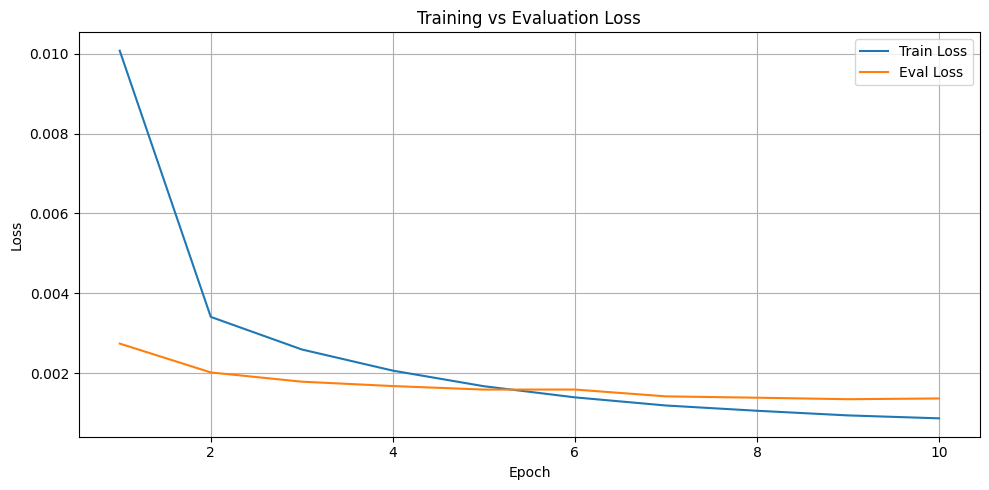

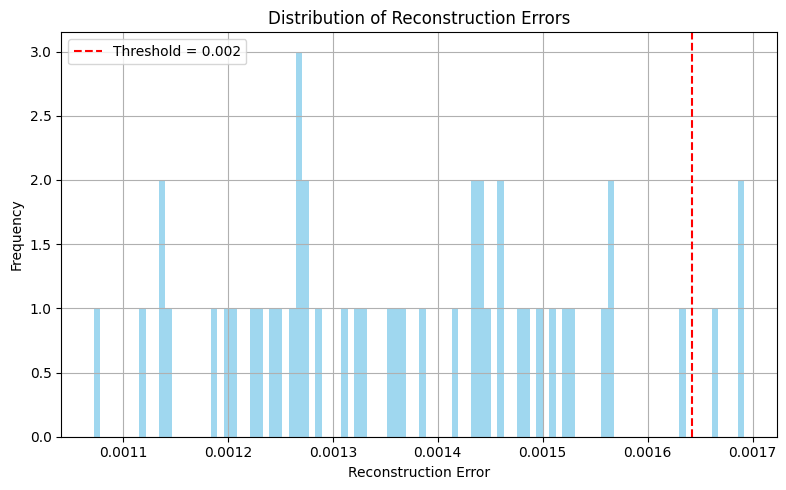

Mean reconstruction error: 0.001370
Std reconstruction error:  0.000158
Anomaly threshold (95th percentile): 0.001642
False positives: 6% out of 47 samples
testing for fp/////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////
false positve rate:0.16690196182890377
actual testing/////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////
                            precision    recall  f1-score   support

                    BENIGN     0.8701    1.0000    0.9305     30033
          Backdoor_Malware     1.0000    0.1025    0.1859       244
                       Bot     1.0000    0.8550    0.9219      1228
          BrowserHijacking     1.0000    0.7860    0.8802       972
          CommandInjection     1.0000    0.3927    0.5640       275
                      DDoS     1.000

c:\Users\youss\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\youss\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


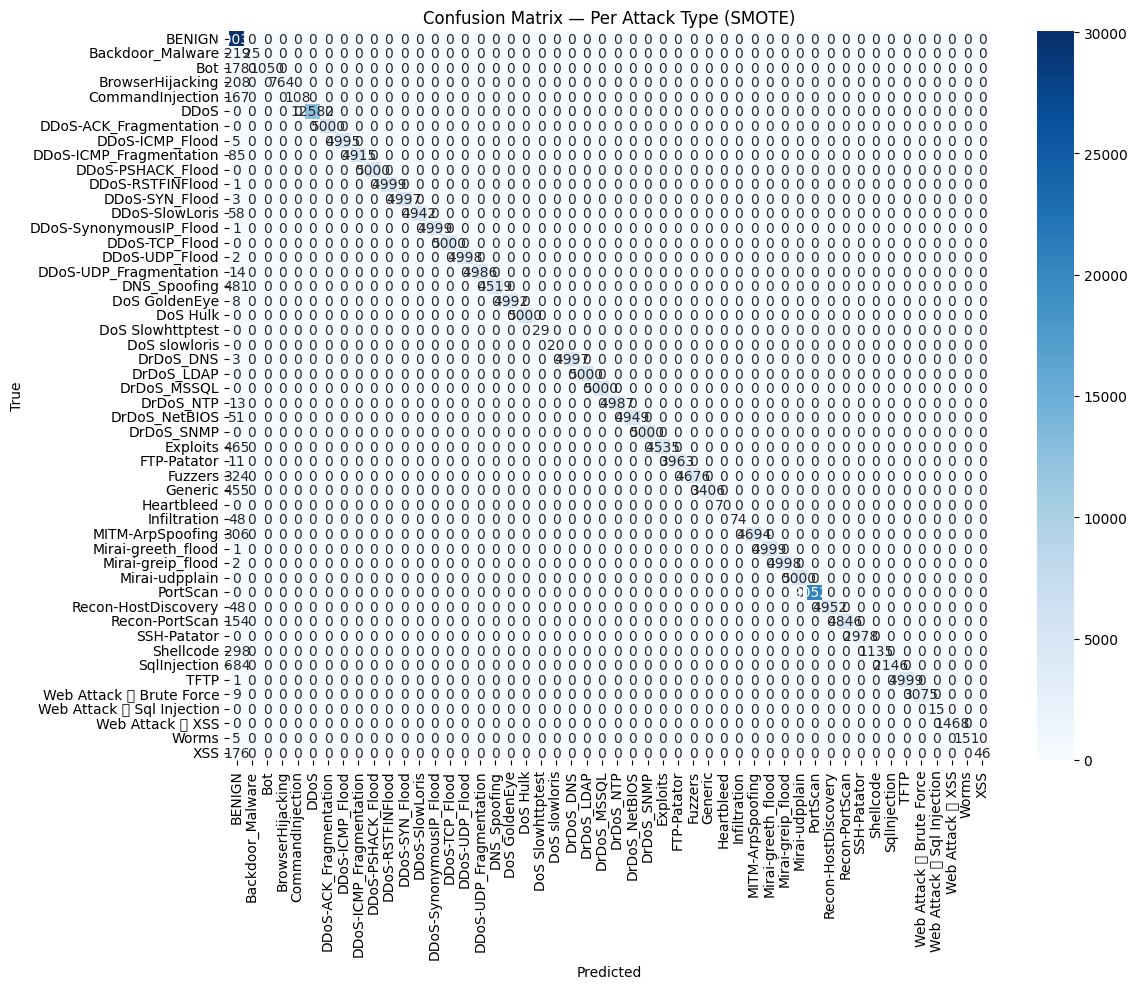

In [ ]:
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm
import dask.dataframe as dd
from sklearn.preprocessing import MinMaxScaler
import copy
from scipy import stats
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, auc
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib
import pandas as pd
import joblib
import random
# Dataset & Model
class NumericDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.data[idx]
# Load and Preprocess Data

random.seed(42)  # set seed once outside
df_big = pd.read_csv("all_attack_and_benign.csv")
df_big = df_big[df_big["label"] == "BENIGN"]  # filter rows where label is benign
df_big=df_big.drop(columns=['label'])
scaler = MinMaxScaler()   #Scale the data to avoid sensitvity to outliers
df_big = scaler.fit_transform(df_big)
df_big=df_big
# Save the fitted scaler for future use
joblib.dump(scaler, "#base_MLP_scaler.pkl")
#/////////////////////////////////////////////////////////////////////////////
#n_samples = int(1 * len(df_big))
#rng = np.random.default_rng(seed=42)   # reproducible like pandas' random_state
#idx = rng.choice(len(df_big), size=n_samples, replace=False)
df = df_big#df_big[idx] #Use only 10 percent

X_train, X_test = train_test_split(df, test_size=0.2, random_state=42)
#  Training Setup
train_dataset = NumericDataset(X_train)
test_dataset = NumericDataset(X_test)
g = torch.Generator()
g.manual_seed(42)
train_loader = DataLoader(train_dataset, batch_size=1880, shuffle=True,generator=g)
test_loader = DataLoader(test_dataset, batch_size=1280, shuffle=False)




class ImprovedAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(ImprovedAutoencoder, self).__init__()
        bottleneck_dim = 4#max(8, input_dim // 6)

        self.encoder = nn.Sequential(
            nn.Linear(88, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(16, 16)
        )

        self.decoder = nn.Sequential(
            nn.Linear(16, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(16, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(512, 88)

        )


    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
# Huber loss is more stable
def robust_loss(output, target, delta=1.0):
    residual = torch.abs(output - target)
    return torch.where(
        residual < delta,
        0.5 * residual**2,
        delta * residual - 0.5 * delta**2
    ).mean()
#  Training Setup
train_dataset = NumericDataset(X_train)
test_dataset = NumericDataset(X_test)
g = torch.Generator()
g.manual_seed(42)
train_loader = DataLoader(train_dataset, batch_size=1882, shuffle=True,generator=g)
test_loader = DataLoader(test_dataset, batch_size=1280, shuffle=False)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

model = ImprovedAutoencoder(input_dim=76).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

NUM_EPOCHS = 10
train_losses = []
eval_losses = []
best_eval=99999999
patience=3
bad=0
best_model=None
#  Training Loop
for epoch in range(NUM_EPOCHS):
    #time.sleep(0.02)
    model.train()
    total_train_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)
    for batch_x, _ in loop:

        batch_x = batch_x.to(device)
        output = model(batch_x)
        loss = robust_loss(output, batch_x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluation
    model.eval()
    total_eval_loss = 0
    with torch.no_grad():
        for batch_x, _ in test_loader:
            batch_x = batch_x.to(device)
            output = model(batch_x)
            loss = criterion(output, batch_x)
            total_eval_loss += loss.item()
    avg_eval_loss = total_eval_loss / len(test_loader)
    eval_losses.append(avg_eval_loss)
    if avg_eval_loss<best_eval :
        print("yay")
        best_eval=avg_eval_loss
        best_model = copy.deepcopy(model.state_dict())
        bad=0
    else:
        bad+=1
    if bad>=patience:
        break


    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Train Loss: {avg_train_loss:.4f}, Eval Loss: {avg_eval_loss:.4f}")




#  Final Evaluation


model.eval()
reconstruction_errors = []
num=0
with torch.no_grad():
    for batch_x, _ in tqdm(test_loader, desc="Evaluating"):
        num+= 1
        batch_x = batch_x.to(device)
        output = model(batch_x)
        loss = criterion(output,batch_x) # MSE
        reconstruction_errors.append(loss.cpu().numpy())
reconstruction_errors = np.array(reconstruction_errors)
print("number of batches:",num)

# Threshold from benign (test) distribution
threshold = np.percentile(reconstruction_errors, 94)


mean_error = reconstruction_errors.mean()

# Classify anomalies (all benign here that are anomalies are actually false positives)
anomalies = reconstruction_errors > threshold
false_positives = anomalies.sum()

# Print results
print(f"Mean reconstruction error: {mean_error:.6f}")
print(f"Anomaly threshold (99th percentile): {threshold:.6f}")
print(f"False positives: {round(false_positives/len(anomalies)* 100)}% out of {len(anomalies)} samples")




print(f"Detected {anomalies.sum()} anomalies out of {len(anomalies)} samples")

#  Save Model
torch.save(best_model, 'mlp_best_numeric_autoencoder.pth')


epochs = range(1, len(train_losses) + 1)

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, eval_losses, label='Eval Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Evaluation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#  Plot 2: Reconstruction Errors
joblib.dump(reconstruction_errors, "all_error")
plt.figure(figsize=(8, 5))
plt.hist(reconstruction_errors, bins=100, color='skyblue', alpha=0.8)
plt.axvline(threshold, color='red', linestyle='--', label=f"Threshold = {threshold:.3f}")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Reconstruction Errors")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# Mean and Std reconstruction error
mean_error = reconstruction_errors.mean()
std_error = reconstruction_errors.std()
print(f"Mean reconstruction error: {mean_error:.6f}")
print(f"Std reconstruction error:  {std_error:.6f}")
print(f"Anomaly threshold (95th percentile): {threshold:.6f}")

print(f"False positives: {round(false_positives/len(anomalies)*100)}% out of {len(anomalies)} samples")

#///////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////
#///////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////
print("testing for fp/////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////")
#testing for fp:
#testing for fp:
fp_rate=0
#df = pd.read_csv('/content/benign-no-label/benign_no_label.csv')




#df.to_csv('attack_no_label2.csv', index=False)


#  Load and Preprocess Malicious & Benign Data

full_benign = df_big


#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()
full_benign_loader = DataLoader(NumericDataset(full_benign), batch_size=128, shuffle=False)

#  Get Reconstruction Errors

def get_reconstruction_errors(loader):
        errors = []
        with torch.no_grad():
            for batch_x, _ in(loader):
                batch_x = batch_x.to(device)
                output = model(batch_x)

                loss = torch.mean((output - batch_x)**2, dim=1)
                errors.extend(loss.cpu().numpy())
        return np.array(errors)


benign_errors = reconstruction_errors
malicious_errors = get_reconstruction_errors(full_benign_loader)#malicous as in its benign but unseen

#  Threshold and Classification
threshold = np.percentile(benign_errors, 94)

benign_preds = benign_errors >threshold
malicious_preds=malicious_errors >threshold

# Metrics
tp = np.sum(malicious_preds)
fp = np.sum(benign_preds)
fn = len(malicious_errors) - tp
tn = len(benign_errors) - fp

precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)
f1 = 2 * precision * recall / (precision + recall + 1e-8)
accuracy = (tp + tn) / (len(benign_errors) + len(malicious_errors))



fp_rate=recall
print(f"false positve rate:{fp_rate}")

#//////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////
#////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////
print("actual testing/////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////")
# ===== ATTACK TESTING =====
from imblearn.over_sampling import SMOTE

df_all =pd.read_csv("all_attack_and_benign.csv")
df_attack = df_all.copy()

#  keep 10 % of benign, all attacks
benign_mask = df_attack["label"] == "BENIGN"
df_attack = pd.concat([df_attack[benign_mask].sample(frac=0.1, random_state=42),
                       df_attack[~benign_mask]])
labels = df_attack["label"].values

df_attack = df_attack.drop(columns=["label"])
df_attack = df_attack.replace([np.inf, -np.inf], np.nan).dropna()
df_attack = df_attack.select_dtypes(include='number')
labels = labels[:len(df_attack)]

sm = SMOTE(random_state=42)
df_attack_resampled, labels_resampled = df_attack,labels#sm.fit_resample(df_attack, labels)

malicious_scaled = scaler.transform(df_attack_resampled)
malicious_loader = DataLoader(NumericDataset(malicious_scaled), batch_size=128, shuffle=False)

malicious_errors = get_reconstruction_errors(malicious_loader)

threshold = np.percentile(benign_errors, 94)

y_true = labels_resampled
#y_true = labels
y_pred = np.where(malicious_errors > threshold, labels_resampled, "BENIGN")
#y_pred = np.where(malicious_errors > threshold, labels, "benign")
all_classes = sorted(np.unique(labels_resampled).tolist())  # remove "benign" from classes
#all_classes = sorted(np.unique(labels).tolist())  # remove "benign" from classes

print(classification_report(y_true, y_pred, labels=all_classes, digits=4))

cm = confusion_matrix(y_true, y_pred, labels=all_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=all_classes, yticklabels=all_classes)
plt.title("Confusion Matrix — Per Attack Type (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()